# Import Packages

In [1]:
from causaldata import texas
from pysyncon import Dataprep, Synth
from pysyncon.utils import PlaceboTest
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Loading Dataset

In [2]:
df = pd.read_csv("data/state_crime.csv")
df = df[df["State"] != "United States"]
df.head()

,State,Year,Data.Population,Data.Rates.Property.All,Data.Rates.Property.Burglary,Data.Rates.Property.Larceny,Data.Rates.Property.Motor,Data.Rates.Violent.All,Data.Rates.Violent.Assault,Data.Rates.Violent.Murder,...,Data.Rates.Violent.Robbery,Data.Totals.Property.All,Data.Totals.Property.Burglary,Data.Totals.Property.Larceny,Data.Totals.Property.Motor,Data.Totals.Violent.All,Data.Totals.Violent.Assault,Data.Totals.Violent.Murder,Data.Totals.Violent.Rape,Data.Totals.Violent.Robbery
0,Alabama,1960,3266740,1035.4,355.9,592.1,87.3,186.6,138.1,12.4,...,27.5,33823,11626,19344,2853,6097,4512,406,281,898
1,Alabama,1961,3302000,985.5,339.3,569.4,76.8,168.5,128.9,12.9,...,19.1,32541,11205,18801,2535,5564,4255,427,252,630
2,Alabama,1962,3358000,1067.0,349.1,634.5,83.4,157.3,119.0,9.4,...,22.5,35829,11722,21306,2801,5283,3995,316,218,754
3,Alabama,1963,3347000,1150.9,376.9,683.4,90.6,182.7,142.1,10.2,...,24.7,38521,12614,22874,3033,6115,4755,340,192,828
4,Alabama,1964,3407000,1358.7,466.6,784.1,108.0,213.1,163.0,9.3,...,29.1,46290,15898,26713,3679,7260,5555,316,397,992


In [3]:
df.shape

(3055, 21)

In [4]:
df.describe()

,Year,Data.Population,Data.Rates.Property.All,Data.Rates.Property.Burglary,Data.Rates.Property.Larceny,Data.Rates.Property.Motor,Data.Rates.Violent.All,Data.Rates.Violent.Assault,Data.Rates.Violent.Murder,Data.Rates.Violent.Rape,Data.Rates.Violent.Robbery,Data.Totals.Property.All,Data.Totals.Property.Burglary,Data.Totals.Property.Larceny,Data.Totals.Property.Motor,Data.Totals.Violent.All,Data.Totals.Violent.Assault,Data.Totals.Violent.Murder,Data.Totals.Violent.Rape,Data.Totals.Violent.Robbery
count,3055.000000,3.055000e+03,3055.000000,3055.000000,3055.000000,3055.000000,3055.000000,3055.000000,3055.000000,3055.000000,3055.000000,3.055000e+03,3055.000000,3055.000000,3055.000000,3055.000000,3055.000000,3055.000000,3055.000000,3055.000000
mean,1989.545008,4.936570e+06,3539.279967,875.013093,2322.420818,341.846809,396.544223,236.799967,6.467398,30.182029,123.092995,1.811803e+05,45653.404255,115857.777087,19669.256956,23382.211784,13536.992144,337.952209,1545.544354,7961.724059
std,17.299204,5.588658e+06,1424.106511,447.990946,902.261469,222.882719,289.337214,160.287987,5.937713,16.803307,144.307696,2.367042e+05,64121.043161,144301.249066,32965.581823,37209.499257,21123.287190,466.184285,2054.869882,14857.425308
min,1960.000000,2.261670e+05,573.100000,126.300000,293.300000,28.400000,9.500000,3.600000,0.200000,0.800000,1.900000,3.147000e+03,751.000000,1489.000000,178.000000,37.000000,14.000000,1.000000,6.000000,8.000000
25%,1975.000000,1.240332e+06,2467.750000,533.350000,1660.650000,183.850000,215.700000,122.950000,3.000000,18.350000,41.850000,3.905850e+04,9239.000000,25684.500000,3146.000000,3249.000000,1993.000000,47.000000,320.000000,790.500000
50%,1990.000000,3.278000e+06,3432.300000,796.000000,2273.200000,286.200000,337.800000,204.000000,5.400000,28.600000,92.800000,1.072080e+05,26549.000000,69915.000000,9163.000000,11015.000000,6567.000000,180.000000,899.000000,3151.000000
75%,2005.000000,5.850104e+06,4431.550000,1131.750000,2877.050000,434.550000,514.800000,319.350000,8.400000,39.900000,151.800000,2.152580e+05,53586.500000,140697.000000,20116.000000,27429.500000,16625.000000,440.500000,1838.000000,7712.500000
max,2019.000000,3.955704e+07,9512.100000,2906.700000,5833.800000,1839.900000,2921.800000,1557.600000,80.600000,161.600000,1635.100000,1.726391e+06,545138.000000,986120.000000,320112.000000,345624.000000,198045.000000,4096.000000,15505.000000,130897.000000


In [5]:
states = df["State"].unique().tolist()
donor_states = [x for x in states if x != "Colorado"]
print(donor_states)

['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']


In [6]:
columns = df.columns.tolist()
print(columns)

['State', 'Year', 'Data.Population', 'Data.Rates.Property.All', 'Data.Rates.Property.Burglary', 'Data.Rates.Property.Larceny', 'Data.Rates.Property.Motor', 'Data.Rates.Violent.All', 'Data.Rates.Violent.Assault', 'Data.Rates.Violent.Murder', 'Data.Rates.Violent.Rape', 'Data.Rates.Violent.Robbery', 'Data.Totals.Property.All', 'Data.Totals.Property.Burglary', 'Data.Totals.Property.Larceny', 'Data.Totals.Property.Motor', 'Data.Totals.Violent.All', 'Data.Totals.Violent.Assault', 'Data.Totals.Violent.Murder', 'Data.Totals.Violent.Rape', 'Data.Totals.Violent.Robbery']


In [7]:
predictors = [x for x in columns if x not in states]
predictors.remove("State")
predictors.remove("Year")
print(predictors)

['Data.Population', 'Data.Rates.Property.All', 'Data.Rates.Property.Burglary', 'Data.Rates.Property.Larceny', 'Data.Rates.Property.Motor', 'Data.Rates.Violent.All', 'Data.Rates.Violent.Assault', 'Data.Rates.Violent.Murder', 'Data.Rates.Violent.Rape', 'Data.Rates.Violent.Robbery', 'Data.Totals.Property.All', 'Data.Totals.Property.Burglary', 'Data.Totals.Property.Larceny', 'Data.Totals.Property.Motor', 'Data.Totals.Violent.All', 'Data.Totals.Violent.Assault', 'Data.Totals.Violent.Murder', 'Data.Totals.Violent.Rape', 'Data.Totals.Violent.Robbery']


In [8]:
final_df = df.pivot(
    index = "Year",
    columns = "State",
    values = predictors
).reset_index()
final_df.head()

Year Data.Population                                              \
State               Alabama    Alaska    Arizona   Arkansas  California   
0      1960       3266740.0  226167.0  1302161.0  1786272.0  15717204.0   
1      1961       3302000.0  234000.0  1391000.0  1797000.0  16397000.0   
2      1962       3358000.0  246000.0  1509000.0  1823000.0  16970000.0   
3      1963       3347000.0  248000.0  1559000.0  1858000.0  17590000.0   
4      1964       3407000.0  250000.0  1581000.0  1933000.0  18084000.0   

                                                             ...  \
State   Colorado Connecticut  Delaware District of Columbia  ...   
0      1753947.0   2535234.0  446292.0             763956.0  ...   
1      1781000.0   2614000.0  458000.0             763956.0  ...   
2      1907000.0   2597000.0  469000.0             784000.0  ...   
3      1961000.0   2666000.0  476000.0             798000.0  ...   
4      1966000.0   2766000.0  491000.0             808000.0  ...   

      Data.Totals.Violent.Robbery                                            \
State                South Dakota Tennessee   Texas   Utah Vermont Virginia   
0                            62.0     961.0  3031.0  185.0     9.0   1042.0   
1                            61.0    1100.0  3042.0  186.0    16.0   1065.0   
2                            62.0    1266.0  3192.0  217.0    18.0   1070.0   
3                            78.0    1048.0  3700.0  225.0    27.0   1267.0   
4                            59.0    1148.0  4479.0  263.0    13.0   1517.0   

                                                  
State Washington West Virginia Wisconsin Wyoming  
0          886.0         238.0     327.0   176.0  
1          902.0         216.0     361.0   121.0  
2          912.0         273.0     348.0    51.0  
3          914.0         260.0     393.0    72.0  
4          850.0         303.0     451.0    46.0  

[5 rows x 970 columns]

In [9]:
fig = make_subplots(rows=len(predictors), cols=1, subplot_titles=predictors)
fig.update_layout(height=300 * len(predictors))

for i, var in enumerate(predictors, 1):
    for state in final_df[var].columns:
        fig.add_trace(
            go.Scatter(x=final_df["Year"], y=final_df[var][state], name=state, showlegend=False,
                       line=dict(color="red" if state == "Texas" else "lightgrey")),
            row=i, col=1
        )

fig.show()

# Assumption Testing

## Convex Hull Assumption Testing

In [10]:
treatment_year = 2014
final_df_pre_treatment = final_df[final_df["Year"] < treatment_year]
for variable in predictors:
    colorado_value = final_df_pre_treatment[variable]["Colorado"].mean()
    donor_min = final_df_pre_treatment[variable][[x for x in states if x != "Colorado"]].min().min()
    donor_max = final_df_pre_treatment[variable][[x for x in states if x!= "Colorado"]].max().max()
    
    if (colorado_value < donor_min) or (colorado_value > donor_max):
        print(f"Colorado outside convex hull on this predictor {variable}.")
    else:
        print(f"Variable {variable} passes convex hull test.")

Variable Data.Population passes convex hull test.
Variable Data.Rates.Property.All passes convex hull test.
Variable Data.Rates.Property.Burglary passes convex hull test.
Variable Data.Rates.Property.Larceny passes convex hull test.
Variable Data.Rates.Property.Motor passes convex hull test.
Variable Data.Rates.Violent.All passes convex hull test.
Variable Data.Rates.Violent.Assault passes convex hull test.
Variable Data.Rates.Violent.Murder passes convex hull test.
Variable Data.Rates.Violent.Rape passes convex hull test.
Variable Data.Rates.Violent.Robbery passes convex hull test.
Variable Data.Totals.Property.All passes convex hull test.
Variable Data.Totals.Property.Burglary passes convex hull test.
Variable Data.Totals.Property.Larceny passes convex hull test.
Variable Data.Totals.Property.Motor passes convex hull test.
Variable Data.Totals.Violent.All passes convex hull test.
Variable Data.Totals.Violent.Assault passes convex hull test.
Variable Data.Totals.Violent.Murder passes 

## Pre-Treatment Fit Assumption Test

In [11]:
df["Year"].unique()

array([1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970,
       1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981,
       1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992,
       1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
       2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014,
       2015, 2016, 2017, 2018, 2019])

In [12]:
control_states = [x for x in df["State"].unique() if x != "Colorado"]

dataprep = Dataprep(
    foo = df,
    predictors = predictors,
    predictors_op = "mean",
    dependent = "Data.Totals.Violent.Assault",
    unit_variable = "State",
    time_variable = "Year",
    treatment_identifier = "Colorado",
    controls_identifier = control_states,
    time_predictors_prior = range(1960, 2013),
    time_optimize_ssr = range(1960, 2013),
    special_predictors=[
        ("Data.Totals.Violent.Assault", range(1960, 2013), "mean"),
        ("Data.Totals.Violent.Assault", range(1960, 2013), "mean"),
    ],)
synth = Synth()
synth.fit(dataprep = dataprep)

In [13]:
print(synth.weights(threshold = 0.01), "\n")
print(synth.summary(), "\n")
print(np.sqrt(synth.mspe()), "\n")

Alaska            0.102
Delaware          0.020
Florida           0.011
Hawaii            0.081
Michigan          0.038
Minnesota         0.029
New Mexico        0.089
Oklahoma          0.035
Oregon            0.176
Rhode Island      0.018
South Carolina    0.015
Utah              0.031
Washington        0.344
Name: weights, dtype: float64 

                                           V      treated    synthetic  \
Data.Population                        0.048  3298695.509  3219775.039   
Data.Rates.Property.All                0.048     4527.126     4525.501   
Data.Rates.Property.Burglary           0.048     1111.874     1110.954   
Data.Rates.Property.Larceny            0.048     3004.847     3004.502   
Data.Rates.Property.Motor              0.048      410.409      410.025   
Data.Rates.Violent.All                 0.048      383.209      383.396   
Data.Rates.Violent.Assault             0.048      235.538      236.359   
Data.Rates.Violent.Murder              0.048        5.126       

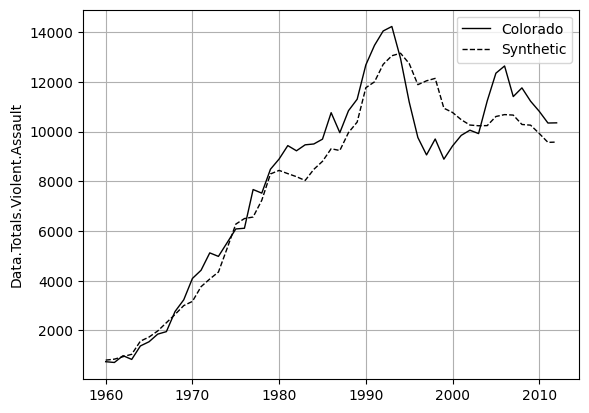

In [14]:
synth.path_plot()

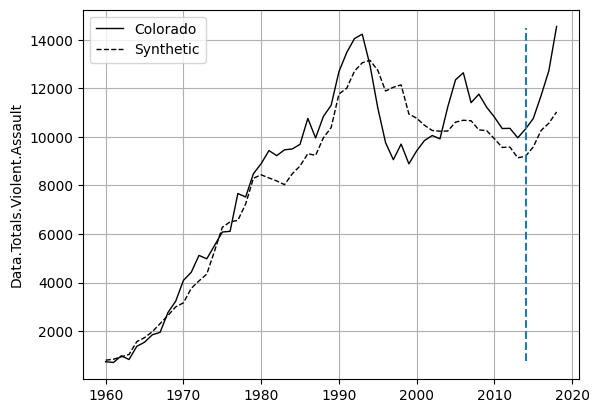

In [15]:
synth.path_plot(
    time_period=range(1960, 2019),
    treatment_time=2014,
)

# Validation: Placebo Test

In [ ]:
placebo = PlaceboTest()
placebo.fit(dataprep=dataprep, scm=Synth(), verbose=True)

(1/50) Completed placebo test for California.
(2/50) Completed placebo test for District of Columbia.
(3/50) Completed placebo test for Florida.
(4/50) Completed placebo test for Alaska.
(5/50) Completed placebo test for Arizona.
(6/50) Completed placebo test for Hawaii.
(7/50) Completed placebo test for Delaware.
(8/50) Completed placebo test for Connecticut.
(9/50) Completed placebo test for Arkansas.
(10/50) Completed placebo test for Alabama.
(11/50) Completed placebo test for Idaho.
(12/50) Completed placebo test for Illinois.
(13/50) Completed placebo test for Georgia.
(14/50) Completed placebo test for Maine.
(15/50) Completed placebo test for Kentucky.


In [ ]:
# Gaps plot 
placebo.gaps_plot(
    time_period=range(1960,2019),
    treatment_time=1993,
    mspe_threshold=5,  
)

# p-value
print(placebo.pvalue(treatment_time=1993))
